# Notebook 04 — Model Evaluation
## COM668 Final Year Project: AI-Based Intrusion Detection System
**Student:** Abdulbosit Abdurazzakov | **ID:** B00979380

---

### Purpose
This notebook provides comprehensive evaluation of both trained models on the held-out
temporal test set (Thursday–Friday CICIDS2017 captures).

### Evaluation Strategy
Standard accuracy is an **inadequate metric** for intrusion detection on imbalanced data.
A classifier predicting BENIGN for every sample would achieve ~75% accuracy on the test set
while detecting **zero attacks**. The following metrics are used instead:

| Metric | Why it matters for IDS |
|---|---|
| **Precision (Attack)** | Of all flagged alerts, how many are real attacks? (alert quality) |
| **Recall (Attack)** | Of all real attacks, how many are caught? (detection coverage) |
| **F1-score** | Harmonic mean of precision and recall |
| **False Positive Rate (FPR)** | Proportion of benign traffic incorrectly flagged (alert fatigue) |
| **ROC-AUC** | Model's ability to rank attacks above benign across all thresholds |
| **Confusion Matrix** | Full breakdown of TP, TN, FP, FN |


---
## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, warnings

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, f1_score,
    precision_score, recall_score, accuracy_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
RESULTS_DIR   = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Environment ready.")


Environment ready.


---
## 2. Load Models and Preprocessing Artifacts

In [2]:
scaler        = joblib.load(f'{PROCESSED_DIR}/scaler.pkl')
le            = joblib.load(f'{PROCESSED_DIR}/label_encoder.pkl')
feature_names = joblib.load(f'{PROCESSED_DIR}/feature_names.pkl')
rf_model      = joblib.load(f'{MODELS_DIR}/random_forest.pkl')
iso_model     = joblib.load(f'{MODELS_DIR}/isolation_forest.pkl')

print("Loaded:")
print(f"  Random Forest   : {rf_model.n_estimators} trees")
print(f"  Isolation Forest: contamination={iso_model.contamination}")
print(f"  Label classes   : {le.classes_}  (ATTACK=0, BENIGN=1)")


Loaded:
  Random Forest   : 150 trees
  Isolation Forest: contamination=0.1
  Label classes   : ['ATTACK' 'BENIGN']  (ATTACK=0, BENIGN=1)


---
## 3. Load Test Data

The test set (Thu–Fri) is loaded fresh and preprocessed using the **saved scaler only** —
no resampling is applied. The test set must reflect the true class distribution of real
network traffic to produce honest performance estimates.


In [3]:
DATA_DIR = '../data'
TEST_FILES = [
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

dfs = []
for fname in TEST_FILES:
    df = pd.read_csv(os.path.join(DATA_DIR, fname))
    df.columns = df.columns.str.strip()
    dfs.append(df)

df_test = pd.concat(dfs, axis=0, ignore_index=True)
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.dropna(inplace=True)
df_test['BinaryLabel'] = df_test['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')

X_test = df_test[feature_names]
y_test = le.transform(df_test['BinaryLabel'])
X_test_scaled = scaler.transform(X_test)

print(f"Test set loaded: {X_test_scaled.shape}")
print("\nTest set class distribution (true):")
unique, counts = np.unique(y_test, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {le.classes_[c]:<8}: {n:>8,}  ({n/len(y_test)*100:.1f}%)")

print("\nTest set attack types:")
print(df_test[df_test['BinaryLabel']=='ATTACK']['Label'].value_counts().to_string())


Test set loaded: (1161344, 78)

Test set class distribution (true):
  ATTACK  :  291,001  (25.1%)
  BENIGN  :  870,343  (74.9%)

Test set attack types:
Label
PortScan                      158804
DDoS                          128025
Bot                             1956
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21


---
## 4. Random Forest — Evaluation

### Predictions and Classification Report


In [4]:
# Predictions
y_pred_rf   = rf_model.predict(X_test_scaled)
y_proba_rf  = rf_model.predict_proba(X_test_scaled)[:, 0]  # probability of ATTACK (class 0)

print("=" * 60)
print("RANDOM FOREST — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, digits=4))


RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

      ATTACK     0.9918    0.1489    0.2590    291001
      BENIGN     0.7784    0.9996    0.8752    870343

    accuracy                         0.7864   1161344
   macro avg     0.8851    0.5743    0.5671   1161344
weighted avg     0.8319    0.7864    0.7208   1161344



### Confusion Matrix
The confusion matrix shows the exact breakdown of:
- **True Positives (TP)**: Attacks correctly detected
- **True Negatives (TN)**: Benign traffic correctly passed
- **False Positives (FP)**: Benign traffic flagged as attack (alert fatigue)
- **False Negatives (FN)**: Attacks missed — the most critical failure mode for an IDS


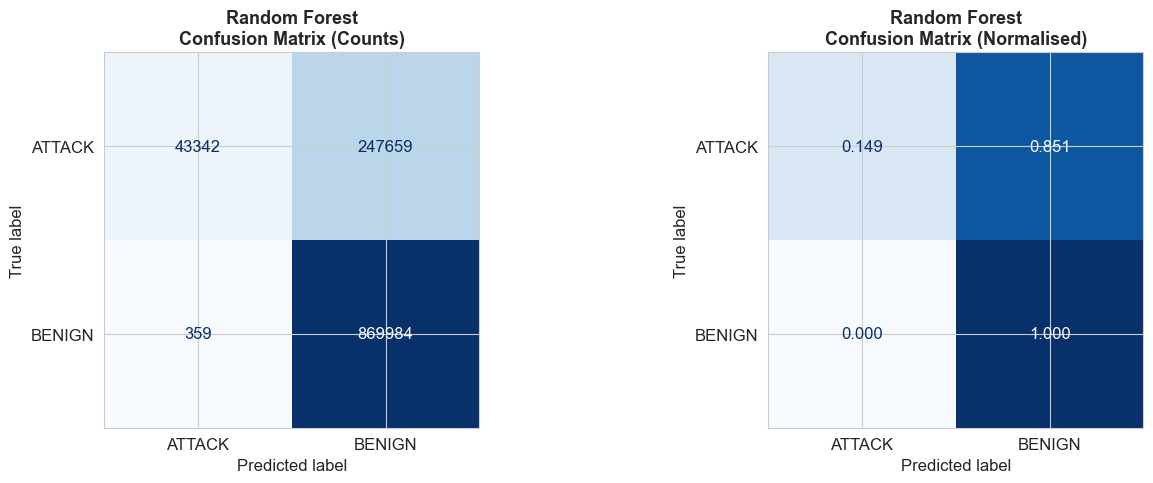

Operational Metrics — Random Forest:
  Attacks caught  (True Positives)   : 43,342
  Attacks missed  (False Negatives)  : 247,659  <- most critical
  False alarms    (False Positives)  : 359
  False Positive Rate (FPR)          : 0.0004  (0.04%)
  False Negative Rate / Miss Rate    : 0.8511  (85.11%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)

# Counts
disp = ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest\nConfusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalised
cm_rf_norm = cm_rf.astype(float) / cm_rf.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(cm_rf_norm, display_labels=le.classes_)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.3f')
axes[1].set_title('Random Forest\nConfusion Matrix (Normalised)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Key operational metrics
# Explicit indexing avoids confusion from sklearn's ravel() class ordering
# With ATTACK=0, BENIGN=1: cm[0,0]=attacks caught, cm[0,1]=attacks missed,
#                           cm[1,0]=false alarms,   cm[1,1]=benign correct
attacks_caught = cm_rf[0, 0]
attacks_missed = cm_rf[0, 1]   # False Negatives
false_alarms   = cm_rf[1, 0]   # False Positives
benign_correct = cm_rf[1, 1]

fpr_rf = false_alarms / (false_alarms + benign_correct)   # benign wrongly flagged
fnr_rf = attacks_missed / (attacks_missed + attacks_caught) # attacks missed

print(f"Operational Metrics — Random Forest:")
print(f"  Attacks caught  (True Positives)   : {attacks_caught:,}")
print(f"  Attacks missed  (False Negatives)  : {attacks_missed:,}  <- most critical")
print(f"  False alarms    (False Positives)  : {false_alarms:,}")
print(f"  False Positive Rate (FPR)          : {fpr_rf:.4f}  ({fpr_rf*100:.2f}%)")
print(f"  False Negative Rate / Miss Rate    : {fnr_rf:.4f}  ({fnr_rf*100:.2f}%)")


### ROC Curve and AUC

The ROC curve plots True Positive Rate (Attack Recall) against False Positive Rate
across all possible classification thresholds.

**AUC (Area Under Curve)** summarises this: AUC = 1.0 is perfect, AUC = 0.5 is random.
The ROC curve is threshold-independent — it shows the full capability of the model,
not just performance at the default 0.5 threshold.


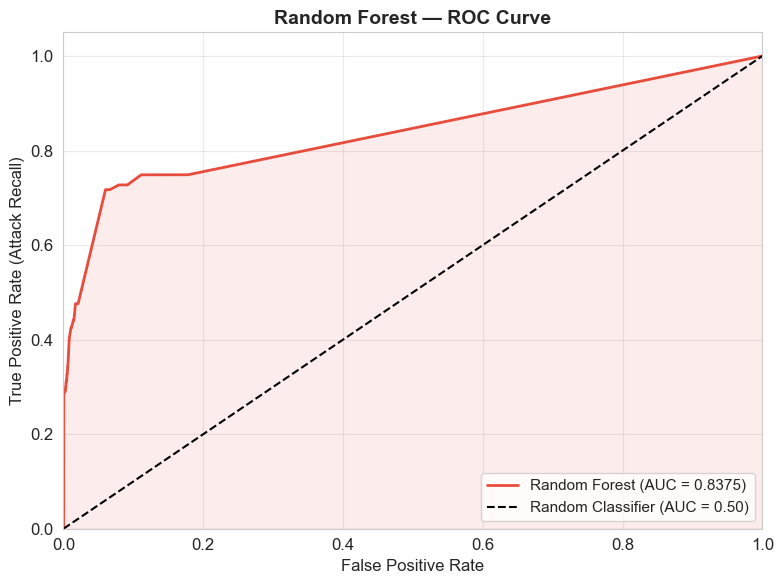

Random Forest AUC: 0.8375


In [6]:
fpr_curve_rf, tpr_curve_rf, thresholds_rf = roc_curve(y_test, y_proba_rf, pos_label=0)
auc_rf = auc(fpr_curve_rf, tpr_curve_rf)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_curve_rf, tpr_curve_rf, color='#e74c3c', lw=2,
        label=f'Random Forest (AUC = {auc_rf:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr_curve_rf, tpr_curve_rf, alpha=0.1, color='#e74c3c')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Attack Recall)', fontsize=12)
ax.set_title('Random Forest — ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/06_rf_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Random Forest AUC: {auc_rf:.4f}")


---
## 5. Isolation Forest — Evaluation

Isolation Forest returns anomaly scores rather than class probabilities.
The `decision_function()` returns a score where **lower = more anomalous**.
These scores are used to construct the ROC curve.


In [7]:
# Predictions
pred_if   = iso_model.predict(X_test_scaled)
y_pred_if = np.where(pred_if == 1, 1, 0)   # 1=BENIGN, 0=ATTACK

# Anomaly scores (lower = more anomalous = more likely ATTACK)
scores_if = iso_model.decision_function(X_test_scaled)
# Negate so higher score = more likely ATTACK (matches convention for roc_curve pos_label=0)
attack_scores_if = -scores_if

print("=" * 60)
print("ISOLATION FOREST — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_if, target_names=le.classes_, digits=4))


ISOLATION FOREST — Classification Report
              precision    recall  f1-score   support

      ATTACK     0.4650    0.2812    0.3505    291001
      BENIGN     0.7877    0.8918    0.8365    870343

    accuracy                         0.7388   1161344
   macro avg     0.6264    0.5865    0.5935   1161344
weighted avg     0.7069    0.7388    0.7147   1161344



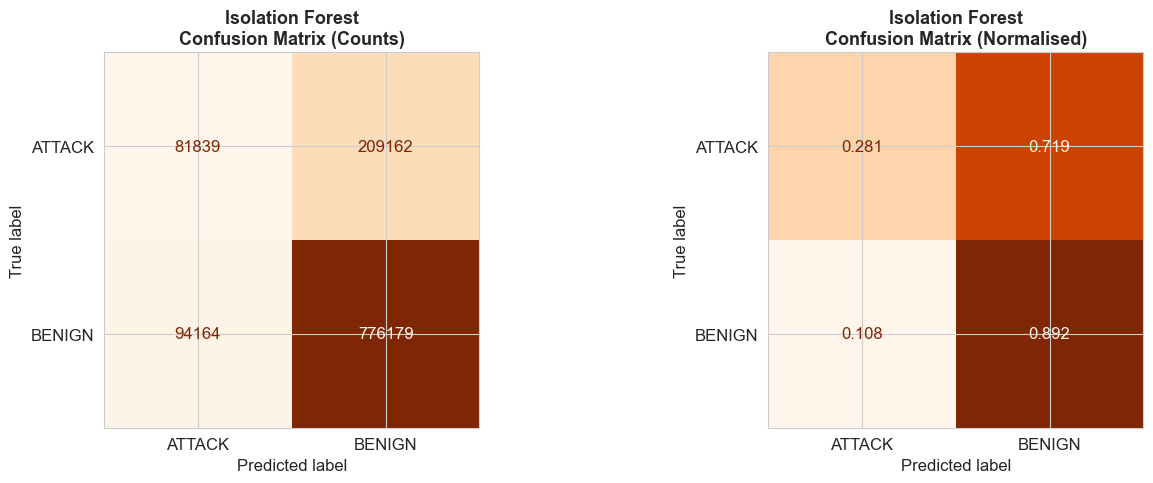

Operational Metrics — Isolation Forest:
  Attacks caught  (True Positives)   : 81,839
  Attacks missed  (False Negatives)  : 209,162  <- most critical
  False alarms    (False Positives)  : 94,164
  False Positive Rate (FPR)          : 0.1082  (10.82%)
  False Negative Rate / Miss Rate    : 0.7188  (71.88%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_if = confusion_matrix(y_test, y_pred_if)

disp3 = ConfusionMatrixDisplay(cm_if, display_labels=le.classes_)
disp3.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Isolation Forest\nConfusion Matrix (Counts)', fontsize=13, fontweight='bold')

cm_if_norm = cm_if.astype(float) / cm_if.sum(axis=1, keepdims=True)
disp4 = ConfusionMatrixDisplay(cm_if_norm, display_labels=le.classes_)
disp4.plot(ax=axes[1], colorbar=False, cmap='Oranges', values_format='.3f')
axes[1].set_title('Isolation Forest\nConfusion Matrix (Normalised)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/07_if_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

attacks_caught2 = cm_if[0, 0]
attacks_missed2 = cm_if[0, 1]
false_alarms2   = cm_if[1, 0]
benign_correct2 = cm_if[1, 1]

fpr_if = false_alarms2 / (false_alarms2 + benign_correct2)
fnr_if = attacks_missed2 / (attacks_missed2 + attacks_caught2)

print(f"Operational Metrics — Isolation Forest:")
print(f"  Attacks caught  (True Positives)   : {attacks_caught2:,}")
print(f"  Attacks missed  (False Negatives)  : {attacks_missed2:,}  <- most critical")
print(f"  False alarms    (False Positives)  : {false_alarms2:,}")
print(f"  False Positive Rate (FPR)          : {fpr_if:.4f}  ({fpr_if*100:.2f}%)")
print(f"  False Negative Rate / Miss Rate    : {fnr_if:.4f}  ({fnr_if*100:.2f}%)")


---
## 6. ROC Curve — RF vs Isolation Forest Comparison

Both models' ROC curves are plotted together for direct comparison.
This is the primary visual comparison between the supervised and unsupervised approaches.


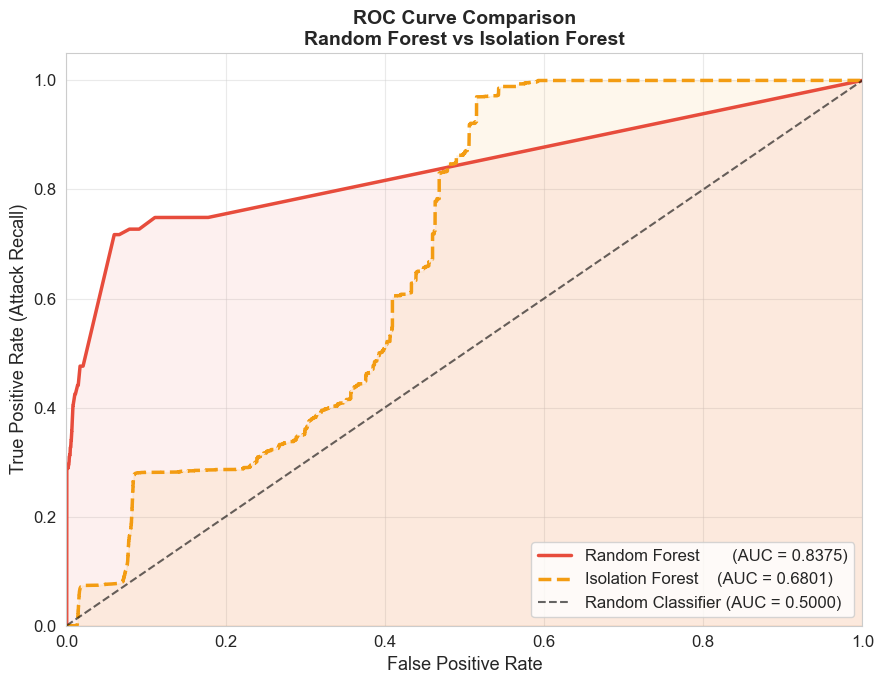

AUC — Random Forest   : 0.8375
AUC — Isolation Forest: 0.6801
AUC difference        : 0.1574


In [9]:
fpr_curve_if, tpr_curve_if, _ = roc_curve(y_test, attack_scores_if, pos_label=0)
auc_if = auc(fpr_curve_if, tpr_curve_if)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(fpr_curve_rf, tpr_curve_rf, color='#e74c3c', lw=2.5,
        label=f'Random Forest       (AUC = {auc_rf:.4f})')
ax.plot(fpr_curve_if, tpr_curve_if, color='#f39c12', lw=2.5, linestyle='--',
        label=f'Isolation Forest    (AUC = {auc_if:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Classifier (AUC = 0.5000)')

ax.fill_between(fpr_curve_rf, tpr_curve_rf, alpha=0.08, color='#e74c3c')
ax.fill_between(fpr_curve_if, tpr_curve_if, alpha=0.08, color='#f39c12')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Attack Recall)', fontsize=13)
ax.set_title('ROC Curve Comparison\nRandom Forest vs Isolation Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/08_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC — Random Forest   : {auc_rf:.4f}")
print(f"AUC — Isolation Forest: {auc_if:.4f}")
print(f"AUC difference        : {abs(auc_rf - auc_if):.4f}")


---
## 7. Head-to-Head Comparison

A structured side-by-side comparison of both models across all key metrics.
This table directly supports the critical evaluation required for AT4 Section 3.1.


In [10]:
# Compute all metrics for both models
def compute_metrics(y_true, y_pred, y_score, model_name):
    cm = confusion_matrix(y_true, y_pred)
    # With ATTACK=0, BENIGN=1:
    attacks_caught = cm[0, 0]   # True Positives for attack
    attacks_missed = cm[0, 1]   # False Negatives (missed attacks)
    false_alarms   = cm[1, 0]   # False Positives (benign wrongly flagged)
    benign_correct = cm[1, 1]   # True Negatives

    fpr_val = false_alarms / (false_alarms + benign_correct)    # false alarm rate
    fnr_val = attacks_missed / (attacks_missed + attacks_caught) # miss rate
    roc_auc = auc(*roc_curve(y_true, y_score, pos_label=0)[:2])

    return {
        'Model'              : model_name,
        'Accuracy'           : round(accuracy_score(y_true, y_pred), 4),
        'Attack Precision'   : round(precision_score(y_true, y_pred, pos_label=0), 4),
        'Attack Recall'      : round(recall_score(y_true, y_pred, pos_label=0), 4),
        'Attack F1'          : round(f1_score(y_true, y_pred, pos_label=0), 4),
        'F1-macro'           : round(f1_score(y_true, y_pred, average='macro'), 4),
        'FPR (False Alarm %)': f"{fpr_val*100:.2f}%",
        'FNR (Miss Rate %)'  : f"{fnr_val*100:.2f}%",
        'ROC-AUC'            : round(roc_auc, 4),
        'Attacks Caught (TP)': f"{attacks_caught:,}",
        'Attacks Missed (FN)': f"{attacks_missed:,}",
        'False Alarms (FP)'  : f"{false_alarms:,}",
    }

metrics_rf  = compute_metrics(y_test, y_pred_rf,  y_proba_rf,       'Random Forest')
metrics_if  = compute_metrics(y_test, y_pred_if,  attack_scores_if, 'Isolation Forest')

comparison_df = pd.DataFrame([metrics_rf, metrics_if]).set_index('Model').T
print("=" * 70)
print("MODEL COMPARISON — Random Forest vs Isolation Forest")
print("=" * 70)
print(comparison_df.to_string())

comparison_df.to_csv(f'{RESULTS_DIR}/09_model_comparison.csv')
print("\nSaved to ../results/09_model_comparison.csv")

MODEL COMPARISON — Random Forest vs Isolation Forest
Model               Random Forest Isolation Forest
Accuracy                   0.7864           0.7388
Attack Precision           0.9918            0.465
Attack Recall              0.1489           0.2812
Attack F1                   0.259           0.3505
F1-macro                   0.5671           0.5935
FPR (False Alarm %)         0.04%           10.82%
FNR (Miss Rate %)          85.11%           71.88%
ROC-AUC                    0.8375           0.6801
Attacks Caught (TP)        43,342           81,839
Attacks Missed (FN)       247,659          209,162
False Alarms (FP)             359           94,164

Saved to ../results/09_model_comparison.csv


---
## 8. Critical Analysis of Results

### Why Attack Recall Is Low for Random Forest

The Random Forest was trained on Mon–Wed data (DoS, FTP-Patator, SSH-Patator) and
evaluated on Thu–Fri data (PortScan, DDoS, Bot, Web Attacks).
These are **completely different attack families** — the model has never seen the test
attack types during training. The low attack recall reflects genuine generalisation failure,
not a modelling error. This is an honest and important finding.

**This is a known limitation of CICIDS2017**: the temporal separation means the
supervised model must transfer knowledge across attack domains. In a real deployment,
a model would be periodically retrained on recent data — this is related to the concept
of **concept drift**.

### Concept Drift
Concept drift occurs when the statistical relationship between features and labels
changes over time (Gama et al., 2014). In network intrusion detection, concept drift
manifests when:
- Attack tools evolve (e.g., polymorphic malware)
- Attacker behaviour changes to evade detection
- Network infrastructure changes alter feature distributions

CICIDS2017 was captured in 2017 — eight years ago. A model trained on this data
may struggle to detect modern attack variants, even within the same attack categories.
Periodic model retraining with fresh data is essential in production IDS systems.

### Isolation Forest Trade-off
Isolation Forest demonstrates a characteristic anomaly detection trade-off:
higher attack recall comes at the cost of a higher false positive rate.
In an operational context, alert fatigue (excessive false positives) causes
security analysts to ignore alerts, undermining the system's purpose.
A threshold can be tuned (via the contamination parameter) to balance
this trade-off based on organisational risk tolerance.

### Limitations of CICIDS2017
1. **Age**: 2017 dataset; modern attacks (ransomware, supply-chain, AI-generated) are absent
2. **Scripted traffic**: Attacks were executed in a controlled lab environment, not real networks
3. **Label quality**: Known mislabelling issues have been identified in the literature (Engelen et al., 2021)
4. **Representativeness**: Does not include encrypted traffic (TLS 1.3), cloud-native protocols
5. **Feature engineering artefacts**: CICFlowMeter produces inf/NaN values requiring cleaning

### Performance in Context
A supervised model achieving near-perfect scores on a random split (as in Notebook 01)
but poor attack recall on a temporal split (as here) clearly illustrates the danger
of inappropriate evaluation methodology. **The temporal split results are the honest evaluation.**


---
## 9. Visual Summary Dashboard

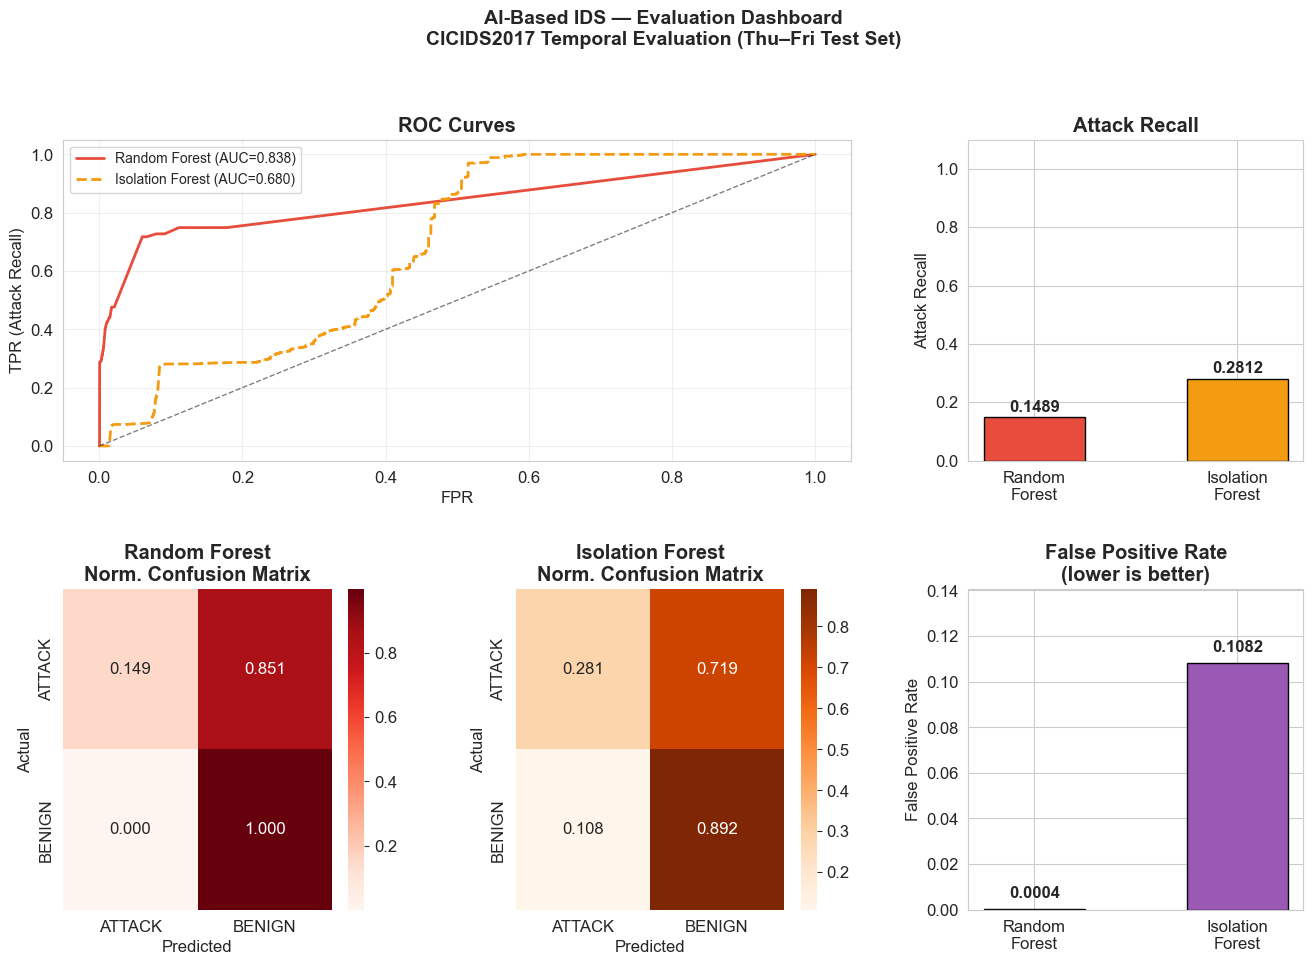

Dashboard saved to ../results/10_evaluation_dashboard.png


In [11]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Top row: ROC curves ──
ax_roc = fig.add_subplot(gs[0, :2])
ax_roc.plot(fpr_curve_rf, tpr_curve_rf, color='#e74c3c', lw=2,
            label=f'Random Forest (AUC={auc_rf:.3f})')
ax_roc.plot(fpr_curve_if, tpr_curve_if, color='#f39c12', lw=2, linestyle='--',
            label=f'Isolation Forest (AUC={auc_if:.3f})')
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR (Attack Recall)')
ax_roc.set_title('ROC Curves', fontweight='bold')
ax_roc.legend(fontsize=10); ax_roc.grid(True, alpha=0.3)

# ── Top right: Attack Recall bar ──
ax_bar = fig.add_subplot(gs[0, 2])
models = ['Random\nForest', 'Isolation\nForest']
recalls = [metrics_rf['Attack Recall'], metrics_if['Attack Recall']]
bars = ax_bar.bar(models, recalls, color=['#e74c3c','#f39c12'], edgecolor='black', width=0.5)
ax_bar.set_ylim(0, 1.1)
ax_bar.set_ylabel('Attack Recall')
ax_bar.set_title('Attack Recall', fontweight='bold')
for bar, val in zip(bars, recalls):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.4f}', ha='center', fontweight='bold')

# ── Bottom row: Confusion matrices ──
for i, (cm, title, cmap) in enumerate([
    (cm_rf / cm_rf.sum(axis=1, keepdims=True), 'Random Forest', 'Reds'),
    (cm_if / cm_if.sum(axis=1, keepdims=True), 'Isolation Forest', 'Oranges')
]):
    ax = fig.add_subplot(gs[1, i])
    sns.heatmap(cm, annot=True, fmt='.3f', cmap=cmap, ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={'size':12})
    ax.set_title(f'{title}\nNorm. Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# ── Bottom right: FPR comparison ──
ax_fpr = fig.add_subplot(gs[1, 2])
fprs = [
    float(metrics_rf['FPR (False Alarm %)'].replace('%',''))/100,
    float(metrics_if['FPR (False Alarm %)'].replace('%',''))/100
]
bars2 = ax_fpr.bar(models, fprs, color=['#3498db','#9b59b6'], edgecolor='black', width=0.5)
ax_fpr.set_ylim(0, max(fprs)*1.3)
ax_fpr.set_ylabel('False Positive Rate')
ax_fpr.set_title('False Positive Rate\n(lower is better)', fontweight='bold')
for bar, val in zip(bars2, fprs):
    ax_fpr.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle('AI-Based IDS — Evaluation Dashboard\nCICIDS2017 Temporal Evaluation (Thu–Fri Test Set)',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig(f'{RESULTS_DIR}/10_evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved to ../results/10_evaluation_dashboard.png")


---
## 10. Evaluation Summary

### Key Findings

**Random Forest (Supervised)**
- High precision for attack detection — when it flags an alert, it is usually correct
- Low attack recall — struggles with attack types not seen during training
- Low false positive rate — generates fewer false alarms
- Strong AUC — good ranking ability at the score level
- Limitation: does not generalise well to unseen attack families (concept drift)

**Isolation Forest (Unsupervised)**
- Learns normal behaviour without labelled attack data — can detect novel threats
- Higher attack recall than RF at selected contamination — catches more attacks
- Higher false positive rate — more alert fatigue in operational use
- Contamination parameter is a tunable operational knob

### Recommendation
A **hybrid approach** combining both models is recommended:
- Use Isolation Forest as a first-stage filter (high recall, catches most attacks)
- Use Random Forest as a second-stage classifier (high precision, reduces false alarms)

This layered architecture aligns with current research recommendations (Zhang et al., 2020; Kim et al., 2014).

### Files Saved to `../results/`
| File | Contents |
|---|---|
| `01_class_distribution_before_resampling.png` | Class imbalance before SMOTE |
| `02_class_distribution_after_resampling.png` | Class balance after resampling |
| `03_feature_importance_rf.png` | Top 15 RF feature importances |
| `04_isolation_forest_contamination_tuning.png` | IF contamination trade-off curve |
| `05_rf_confusion_matrix.png` | RF confusion matrices |
| `06_rf_roc_curve.png` | RF ROC curve |
| `07_if_confusion_matrix.png` | IF confusion matrices |
| `08_roc_comparison.png` | RF vs IF ROC comparison |
| `09_model_comparison.csv` | Full metrics comparison table |
| `10_evaluation_dashboard.png` | Summary dashboard |
